# Denoising Diffusion Probabilistic Models (DDPM)

**Paper:** Ho, Jain & Abbeel (2020) — *Denoising Diffusion Probabilistic Models*

A PyTorch implementation trained on the Smithsonian Butterflies dataset.

---

## 1. Imports and Configuration

In [ ]:
!pip install datasets

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
IMG_SIZE = 128
CHANNELS = 3
T = 1000            # number of diffusion timesteps
BATCH_SIZE = 32
EPOCHS = 20
LR = 2e-4

Using device: cuda


## 2. Forward Diffusion Process (Noise Schedule)

The forward process gradually adds Gaussian noise to a data sample $\mathbf{x}_0$ over $T$ timesteps using a variance schedule $\{\beta_t\}_{t=1}^{T}$:

$$q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\!\left(\mathbf{x}_t;\; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\; \beta_t\,\mathbf{I}\right)$$

Define $\alpha_t = 1-\beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$. Then we can sample $\mathbf{x}_t$ directly from $\mathbf{x}_0$ in closed form:

$$q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\!\left(\mathbf{x}_t;\; \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\; (1-\bar{\alpha}_t)\,\mathbf{I}\right)$$

Using the **reparameterization trick**:

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$$

In [19]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Linear variance schedule from β_start to β_end."""
    return torch.linspace(beta_start, beta_end, timesteps)

# Precompute diffusion constants
betas = linear_beta_schedule(T).to(device)                    # β_t
alphas = 1.0 - betas                                          # α_t
alphas_cumprod = torch.cumprod(alphas, dim=0)                  # ᾱ_t
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)  # ᾱ_{t-1}

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)               # √ᾱ_t
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)  # √(1-ᾱ_t)

# For posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def forward_diffusion(x_0, t, noise=None):
    """
    Sample x_t from q(x_t | x_0) using the reparameterization trick.
    x_t = √ᾱ_t * x_0  +  √(1-ᾱ_t) * ε
    """
    if noise is None:
        noise = torch.randn_like(x_0)

    sqrt_alpha = sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

    return sqrt_alpha * x_0 + sqrt_one_minus_alpha * noise, noise

### Visualize the Forward Process

Load the Smithsonian Butterflies dataset and show samples being progressively noised at selected timesteps.

Repo card metadata block was not found. Setting CardData to empty.


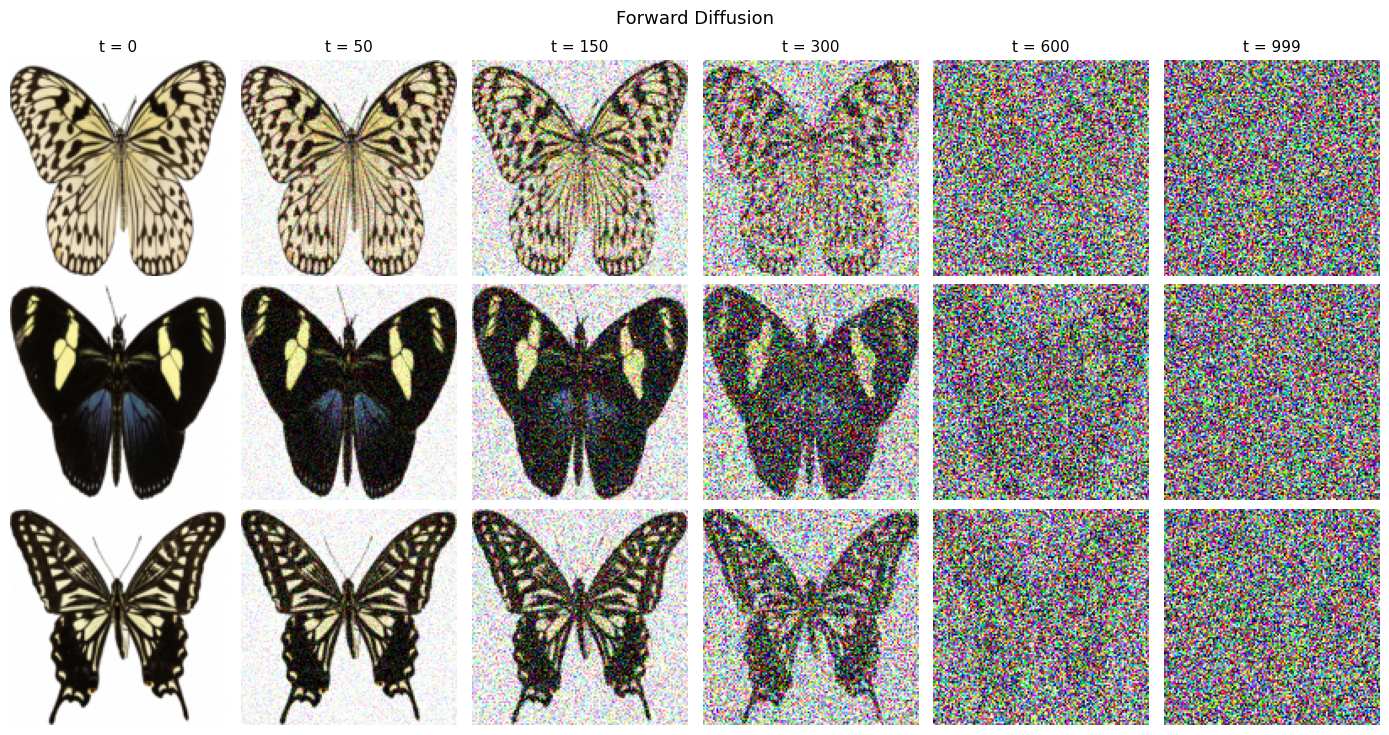

In [20]:
# Load Smithsonian Butterflies — normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

hf_dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

class ButterflyDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img = self.dataset[idx]["image"].convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label for compatibility

train_dataset = ButterflyDataset(hf_dataset, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)

# Visualize forward diffusion for sample images
N_SAMPLES = 3
timesteps_to_show = [0, 50, 150, 300, 600, 999]

fig, axes = plt.subplots(N_SAMPLES, len(timesteps_to_show), figsize=(14, 2.5 * N_SAMPLES))
for row in range(N_SAMPLES):
    sample_img = train_dataset[row][0].unsqueeze(0).to(device)  # (1, 3, 128, 128)
    for col, t_val in enumerate(timesteps_to_show):
        t_tensor = torch.tensor([t_val], device=device)
        noisy, _ = forward_diffusion(sample_img, t_tensor)
        # Convert from (C, H, W) [-1, 1] to (H, W, C) [0, 1] for display
        img = (noisy.squeeze().cpu().clamp(-1, 1) + 1) / 2
        axes[row, col].imshow(img.permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t = {t_val}", fontsize=11)

plt.suptitle("Forward Diffusion", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Noise Prediction Network (U-Net with Time Embedding)

The reverse process is parameterized by a neural network $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ that predicts the noise $\boldsymbol{\epsilon}$ given the noisy image $\mathbf{x}_t$ and the timestep $t$.

### Sinusoidal Timestep Embedding

Following the Transformer positional encoding, the timestep $t$ is embedded as:

$$\text{PE}(t, 2i) = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad \text{PE}(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

where $d$ is the embedding dimension and $i$ is the dimension index.

### U-Net Architecture

The model follows an encoder-decoder structure with skip connections:

$$\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) = \text{Decoder}\!\Big(\text{Encoder}(\mathbf{x}_t) + \text{TimeEmbed}(t)\Big)$$

- **Encoder:** 4 downsampling blocks (128→64→32→16→8) with time-conditioned residual connections.
- **Bottleneck:** Two residual blocks processing the 8×8 features.
- **Decoder:** 4 upsampling blocks with skip connections from the encoder.

In [21]:
class SinusoidalPositionEmbedding(nn.Module):
    """Sinusoidal timestep embedding: PE(t,2i) = sin(t/10000^{2i/d}), PE(t,2i+1) = cos(t/10000^{2i/d})."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)


class ResBlock(nn.Module):
    """Residual block with time-conditioning: h = x + Conv(GN(SiLU(Conv(GN(SiLU(x))) + time_proj)))."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_mlp(F.silu(t_emb)).unsqueeze(-1).unsqueeze(-1)
        h = F.silu(self.norm2(h))
        h = self.conv2(h)
        return h + self.shortcut(x)


class SimpleUNet(nn.Module):
    """
    U-Net for 128×128 butterfly images.
    Encoder:  128→64→32→16→8   (4 downsampling steps)
    Decoder:  8→16→32→64→128   (4 upsampling steps with skip connections)
    """
    def __init__(self, in_ch=3, base_ch=128, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        # Initial projection from input channels to base_ch
        self.init_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        # Encoder
        self.enc1 = ResBlock(base_ch, base_ch, time_dim)                           # 128×128
        self.down1 = nn.Conv2d(base_ch, base_ch, 3, stride=2, padding=1)           # →64×64
        self.enc2 = ResBlock(base_ch, base_ch, time_dim)                           # 64×64
        self.down2 = nn.Conv2d(base_ch, base_ch, 3, stride=2, padding=1)           # →32×32
        self.enc3 = ResBlock(base_ch, base_ch * 2, time_dim)                       # 32×32
        self.down3 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, stride=2, padding=1)  # →16×16
        self.enc4 = ResBlock(base_ch * 2, base_ch * 2, time_dim)                  # 16×16
        self.down4 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, stride=2, padding=1)  # →8×8
        # Bottleneck
        self.mid1 = ResBlock(base_ch * 2, base_ch * 2, time_dim)                  # 8×8
        self.mid2 = ResBlock(base_ch * 2, base_ch * 2, time_dim)                  # 8×8
        # Decoder
        self.up4 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 2, stride=2)      # →16×16
        self.dec4 = ResBlock(base_ch * 4, base_ch * 2, time_dim)                  # skip: 256+256→256
        self.up3 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 2, stride=2)      # →32×32
        self.dec3 = ResBlock(base_ch * 4, base_ch, time_dim)                       # skip: 256+256→128
        self.up2 = nn.ConvTranspose2d(base_ch, base_ch, 2, stride=2)              # →64×64
        self.dec2 = ResBlock(base_ch * 2, base_ch, time_dim)                       # skip: 128+128→128
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 2, stride=2)              # →128×128
        self.dec1 = ResBlock(base_ch * 2, base_ch, time_dim)                       # skip: 128+128→128
        # Output
        self.out = nn.Sequential(
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 1),
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x = self.init_conv(x)                            # (B, 128, 128, 128)
        # Encoder
        e1 = self.enc1(x, t_emb)                         # (B, 128, 128, 128)
        e2 = self.enc2(self.down1(e1), t_emb)             # (B, 128, 64, 64)
        e3 = self.enc3(self.down2(e2), t_emb)             # (B, 256, 32, 32)
        e4 = self.enc4(self.down3(e3), t_emb)             # (B, 256, 16, 16)
        # Bottleneck
        m = self.mid1(self.down4(e4), t_emb)              # (B, 256, 8, 8)
        m = self.mid2(m, t_emb)                           # (B, 256, 8, 8)
        # Decoder + skip connections
        d4 = self.dec4(torch.cat([self.up4(m), e4], dim=1), t_emb)   # (B, 256, 16, 16)
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1), t_emb)  # (B, 128, 32, 32)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)  # (B, 128, 64, 64)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)  # (B, 128, 128, 128)
        return self.out(d1)

model = SimpleUNet(in_ch=CHANNELS).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {total_params:,}")

U-Net parameters: 11,474,563


## 4. Training Objective

The variational lower bound can be simplified to a **noise prediction** loss (Ho et al., 2020):

$$L_{\text{simple}} = \mathbb{E}_{t \sim \mathcal{U}(1,T),\; \mathbf{x}_0 \sim q(\mathbf{x}_0),\; \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})} \Big[\left\| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta\!\left(\mathbf{x}_t, t\right) \right\|^2 \Big]$$

**Training algorithm:**
1. Sample $\mathbf{x}_0 \sim q(\mathbf{x}_0)$ (a batch from the dataset)
2. Sample $t \sim \text{Uniform}(\{1, \dots, T\})$
3. Sample $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
4. Compute $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}$
5. Gradient step on $\nabla_\theta \left\| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right\|^2$

In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# Cosine annealing with linear warmup
WARMUP_EPOCHS = 5
steps_per_epoch = len(train_loader)

def lr_lambda(step):
    warmup_steps = WARMUP_EPOCHS * steps_per_epoch
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, EPOCHS * steps_per_epoch - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def train_one_epoch(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    for x_0, _ in dataloader:
        x_0 = x_0.to(device)
        t = torch.randint(0, T, (x_0.shape[0],), device=device)
        noise = torch.randn_like(x_0)
        x_t, _ = forward_diffusion(x_0, t, noise)
        noise_pred = model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

## 5. Reverse Process (Sampling / Denoising)

Starting from pure noise $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, we iteratively denoise using:

$$p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t) = \mathcal{N}\!\left(\mathbf{x}_{t-1};\; \boldsymbol{\mu}_\theta(\mathbf{x}_t, t),\; \sigma_t^2\,\mathbf{I}\right)$$

The predicted mean is computed from the predicted noise $\boldsymbol{\epsilon}_\theta$:

$$\boldsymbol{\mu}_\theta(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right)$$

The variance is set to $\sigma_t^2 = \beta_t$ (or the posterior variance $\tilde{\beta}_t$).

**Sampling algorithm:**
1. $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. **For** $t = T, T{-}1, \dots, 1$:
   - $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ if $t > 1$, else $\mathbf{z} = \mathbf{0}$
   - $\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right) + \sigma_t\,\mathbf{z}$
3. **Return** $\mathbf{x}_0$

---

<details>
<summary><strong> Optional — Derivation of the predicted mean</strong></summary>

**Goal:** compute the tractable posterior $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0)$ and then substitute $\mathbf{x}_0$ with a prediction from the model.

**Step 1 — Posterior by Bayes' rule**

Using $q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}(\sqrt{\bar\alpha_t}\,\mathbf{x}_0,\,(1-\bar\alpha_t)\mathbf{I})$ and $q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}(\sqrt{\alpha_t}\,\mathbf{x}_{t-1},\,\beta_t\mathbf{I})$:

$$q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) \propto q(\mathbf{x}_t \mid \mathbf{x}_{t-1})\, q(\mathbf{x}_{t-1} \mid \mathbf{x}_0)$$

Completing the square in the exponents yields a Gaussian with:

$$\tilde{\boldsymbol{\mu}}_t(\mathbf{x}_t, \mathbf{x}_0) = \frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1 - \bar{\alpha}_t}\,\mathbf{x}_0 + \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}\,\mathbf{x}_t, \qquad \tilde\beta_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t}\,\beta_t$$

**Step 2 — Substitute $\mathbf{x}_0$ with the model's prediction**

From the forward reparameterization trick we can invert for $\mathbf{x}_0$:

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon} \quad\Longrightarrow\quad \hat{\mathbf{x}}_0 = \frac{1}{\sqrt{\bar{\alpha}_t}}\!\left(\mathbf{x}_t - \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\right)$$

**Step 3 — Plug $\hat{\mathbf{x}}_0$ into $\tilde{\boldsymbol{\mu}}_t$**

Substituting and simplifying using $\alpha_t = 1 - \beta_t$:

$$\boldsymbol{\mu}_\theta(\mathbf{x}_t, t) = \frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1 - \bar{\alpha}_t} \cdot \frac{\mathbf{x}_t - \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}_\theta}{\sqrt{\bar{\alpha}_t}} + \frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}\,\mathbf{x}_t$$

After algebraic simplification (collecting $\mathbf{x}_t$ and $\boldsymbol{\epsilon}_\theta$ terms) this reduces to:

$$\boxed{\boldsymbol{\mu}_\theta(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right)}$$

</details>

In [23]:
@torch.no_grad()
def sample(model, n_samples=16):
    """Generate images by sampling from the reverse process."""
    model.eval()
    # Step 1: Start from pure noise x_T ~ N(0, I)
    x = torch.randn(n_samples, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)

    for t_val in reversed(range(T)):
        t_batch = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        # Predict noise
        eps_pred = model(x, t_batch)
        # Compute μ_θ(x_t, t)
        alpha_t = alphas[t_val]
        alpha_bar_t = alphas_cumprod[t_val]
        beta_t = betas[t_val]
        mu = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred)
        # Add noise (except at t=0)
        if t_val > 0:
            sigma = torch.sqrt(beta_t)
            z = torch.randn_like(x)
            x = mu + sigma * z
        else:
            x = mu

    # Clamp to [-1, 1] and rescale to [0, 1] for display
    x = (x.clamp(-1, 1) + 1) / 2
    return x

## 6. Train the Model on Smithsonian Butterflies

In [ ]:
losses = []
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    losses.append(avg_loss)
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:02d}/{EPOCHS} — Loss: {avg_loss:.4f}  LR: {current_lr:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(range(1, EPOCHS + 1), losses, marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

total_steps = EPOCHS * steps_per_epoch
lrs = [lr_lambda(s) * LR for s in range(total_steps)]
ax2.plot(lrs)
ax2.set_xlabel("Step")
ax2.set_ylabel("Learning Rate")
ax2.set_title("LR Schedule (warmup + cosine decay)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualize the Reverse (Denoising) Process

Show a single sample being progressively denoised from $\mathbf{x}_T$ (pure noise) to $\mathbf{x}_0$ (generated image).

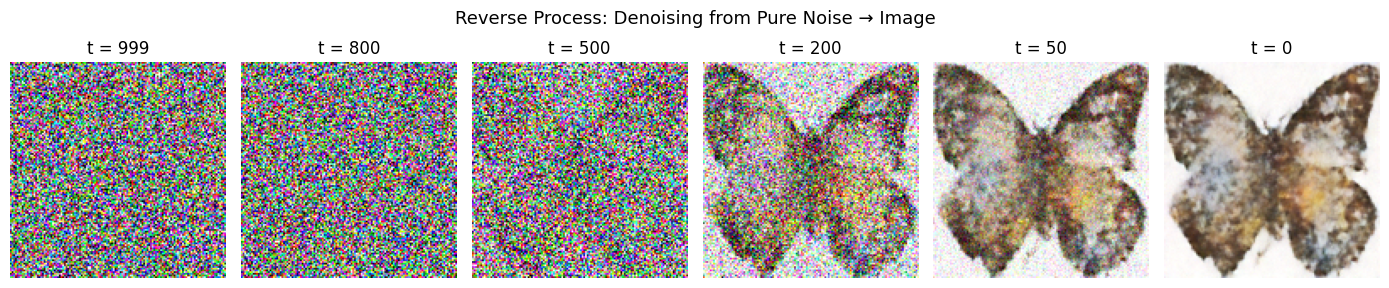

In [29]:
@torch.no_grad()
def sample_with_trajectory(model, steps_to_save=None):
    """Sample one image and capture intermediates at specified timesteps."""
    if steps_to_save is None:
        steps_to_save = [999, 800, 500, 200, 50, 0]
    model.eval()
    x = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    trajectory = {}

    for t_val in reversed(range(T)):
        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        alpha_t = alphas[t_val]
        alpha_bar_t = alphas_cumprod[t_val]
        beta_t = betas[t_val]
        mu = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred)
        if t_val > 0:
            x = mu + torch.sqrt(beta_t) * torch.randn_like(x)
        else:
            x = mu
        if t_val in steps_to_save:
            # (C, H, W) → (H, W, C), rescale to [0, 1]
            trajectory[t_val] = ((x.clamp(-1, 1) + 1) / 2).squeeze().cpu().permute(1, 2, 0).numpy()
    return trajectory

traj = sample_with_trajectory(model)
fig, axes = plt.subplots(1, len(traj), figsize=(14, 3))
for i, (t_val, img) in enumerate(sorted(traj.items(), reverse=True)):
    axes[i].imshow(img)
    axes[i].set_title(f"t = {t_val}")
    axes[i].axis("off")
plt.suptitle("Reverse Process: Denoising from Pure Noise → Image", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

@torch.no_grad()
def sample_full_trajectory(model):
    """Run the full reverse diffusion and return every frame as a numpy image."""
    model.eval()
    x = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    frames = []

    for t_val in reversed(range(T)):
        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        alpha_t     = alphas[t_val]
        alpha_bar_t = alphas_cumprod[t_val]
        beta_t      = betas[t_val]
        mu = (1.0 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
        )
        x = mu + torch.sqrt(beta_t) * torch.randn_like(x) if t_val > 0 else mu

        # Save a frame every 10 steps so the GIF stays small
        if t_val % 10 == 0 or t_val == T - 1:
            # (C, H, W) → (H, W, C), rescale to [0, 1]
            img_np = ((x.clamp(-1, 1) + 1) / 2).squeeze().cpu().permute(1, 2, 0).numpy()
            frames.append(img_np)

    return frames  # ordered: noisy → clean


def frames_to_gif(frames, path="denoising.gif", scale=4, fps=20):
    """Save a list of float [0,1] RGB numpy arrays as an animated GIF."""
    pil_frames = []
    for f in frames:
        arr = (f * 255).astype("uint8")
        img = Image.fromarray(arr, mode="RGB").resize(
            (arr.shape[1] * scale, arr.shape[0] * scale),
            resample=Image.NEAREST,
        )
        pil_frames.append(img)

    duration_ms = int(1000 / fps)
    pil_frames[0].save(
        path,
        save_all=True,
        append_images=pil_frames[1:],
        loop=0,           # loop forever
        duration=duration_ms,
    )
    print(f"GIF saved → {path}  ({len(pil_frames)} frames @ {fps} fps)")


frames = sample_full_trajectory(model)
frames_to_gif(frames, path="denoising.gif", scale=4, fps=20)

# ── Inline preview: first / mid / last frame ─────────────────────────────────
preview_indices = [0, len(frames) // 2, len(frames) - 1]
preview_labels  = [f"Pure noise (t={T-1})", f"Midpoint (t≈{T//2})", "Clean (t=0)"]

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
for ax, idx, label in zip(axes, preview_indices, preview_labels):
    ax.imshow(frames[idx])
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.suptitle("Denoising GIF — key frames preview", fontsize=11)
plt.tight_layout()
plt.show()
